> Part of **Complete Machine Learning Study Material** — split across per-chapter notebooks. See [`00_index.ipynb`](00_index.ipynb) for the notebook conventions, the per-concept template, the chapter coverage tracker and the cross-reference index.

## 10. Optimization and Gradient Descent

*Scope:* The engine underneath most of the supervised chapters: a loss function, a gradient, and a rule for taking the next step.

Chapters 11 and 13 both end at the same place: a loss function, a gradient, and a rule for taking the next
step. This chapter builds that machinery once, so those chapters can use it rather than re-derive it.

2.6 supplied the calculus — the gradient points uphill, so descent goes the other way, and any hand-derived
gradient should be checked numerically. Everything here is that idea turned into an algorithm.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

pd.set_option("display.width", 110)
sns.set_theme(style="whitegrid")
print("ready")

ready


### 10.1 Learning as Optimization

Nearly every supervised model in this material is fitted by the same three-part recipe:

| Part | Is | Chosen by |
|---|---|---|
| **A model** $\hat{y} = f(\mathbf{x}; \theta)$ | A family of functions with parameters $\theta$ | You (Chapters 11–19) |
| **A loss** $J(\theta)$ | How wrong the parameters are on the training data | You (10.2) |
| **An optimizer** | A procedure for finding $\theta$ that minimizes $J$ | Usually the library (10.4–10.8) |

"Training" means solving $\theta^{\star} = \arg\min_{\theta} J(\theta)$. Different models change $f$;
different tasks change $J$; the optimizer is often the same code underneath.

In [2]:
# The whole recipe on a one-parameter problem, so every piece is visible.
x = np.linspace(-2, 2, 60)
y = 3.0 * x + rng.normal(0, 0.6, 60)          # true slope 3.0, no intercept

def model(w, x):                                # the MODEL
    return w * x

def loss(w):                                    # the LOSS: mean squared error
    return np.mean((model(w, x) - y) ** 2)

candidates = np.linspace(-1, 7, 9)
for w in candidates[::2]:
    print(f"w = {w:>5.1f}   J(w) = {loss(w):>8.3f}")

w =  -1.0   J(w) =   22.615
w =   1.0   J(w) =    5.903
w =   3.0   J(w) =    0.220
w =   5.0   J(w) =    5.565
w =   7.0   J(w) =   21.938


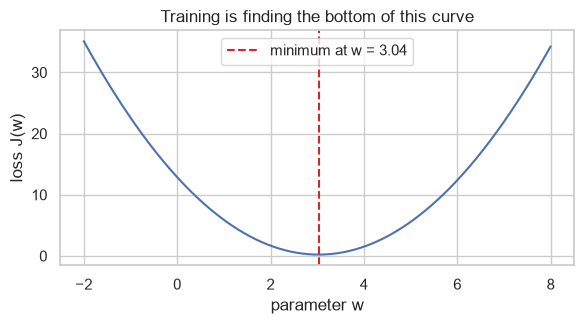

In [3]:
w_grid = np.linspace(-2, 8, 400)
J = np.array([loss(w) for w in w_grid])

fig, ax = plt.subplots(figsize=(6, 3.4))
ax.plot(w_grid, J)
ax.axvline(w_grid[J.argmin()], color="tab:red", ls="--",
           label=f"minimum at w = {w_grid[J.argmin()]:.2f}")
ax.set_xlabel("parameter w"); ax.set_ylabel("loss J(w)")
ax.set_title("Training is finding the bottom of this curve")
ax.legend()
fig.tight_layout()
plt.show()

With one parameter the minimum can be found by drawing the curve. With ten it cannot, and with a thousand
the surface cannot even be stored. **Gradient descent exists because you can compute the slope at a point
without ever seeing the whole surface.**

### 10.2 Loss Functions

The loss defines what "wrong" means, and therefore what the model optimizes for. Choosing it is a modelling
decision, not an implementation detail — 8.4.1 already showed MAE and RMSE disagreeing by a factor of ten
about which of two error patterns is worse.

#### 10.2.1 Regression losses

| Loss | Formula | Penalizes large errors | Robust to outliers | Differentiable everywhere |
|---|---|---|---|---|
| **Squared (L2)** | $(y - \hat{y})^2$ | Quadratically | **No** | Yes |
| **Absolute (L1)** | $\lvert y - \hat{y} \rvert$ | Linearly | **Yes** | No (kink at 0) |
| **Huber** | Quadratic near 0, linear far out | Linearly in the tail | **Yes** | Yes |
| **Epsilon-insensitive** | 0 inside a tube, linear outside | Linearly | Yes | No |

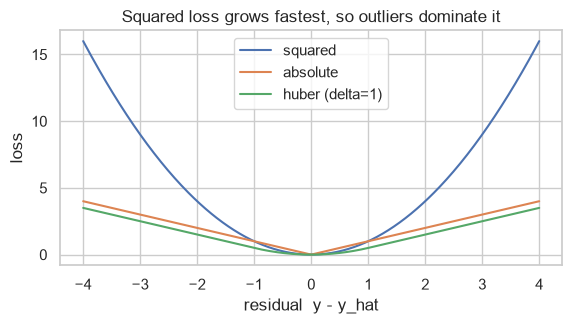

In [4]:
def squared_loss(r):
    return r ** 2

def absolute_loss(r):
    return np.abs(r)

def huber_loss(r, delta=1.0):
    return np.where(np.abs(r) <= delta, 0.5 * r ** 2, delta * (np.abs(r) - 0.5 * delta))


residual = np.linspace(-4, 4, 400)
fig, ax = plt.subplots(figsize=(6, 3.4))
ax.plot(residual, squared_loss(residual), label="squared")
ax.plot(residual, absolute_loss(residual), label="absolute")
ax.plot(residual, huber_loss(residual), label="huber (delta=1)")
ax.set_xlabel("residual  y - y_hat"); ax.set_ylabel("loss")
ax.set_title("Squared loss grows fastest, so outliers dominate it")
ax.legend()
fig.tight_layout()
plt.show()

The consequence is concrete: because squared loss grows quadratically, a single distant point pulls the
fitted line towards itself much harder than several nearby points push back.

In [5]:
from sklearn.linear_model import LinearRegression, HuberRegressor

x_out = np.linspace(0, 10, 40).reshape(-1, 1)
y_out = 2.0 * x_out.ravel() + 1 + rng.normal(0, 1.0, 40)
y_out[-1] += 40.0        # one gross outlier

ols = LinearRegression().fit(x_out, y_out)
huber = HuberRegressor(epsilon=1.35).fit(x_out, y_out)

print(f"true slope             : 2.000")
print(f"squared loss (OLS)     : {ols.coef_[0]:.3f}   <- dragged by one point")
print(f"huber loss             : {huber.coef_[0]:.3f}")

true slope             : 2.000
squared loss (OLS)     : 2.520   <- dragged by one point
huber loss             : 1.967


#### 10.2.2 Classification losses

Classification cannot optimize accuracy directly: accuracy is a step function of the parameters, so its
gradient is zero almost everywhere and undefined at the steps. Every practical classification loss is a
**differentiable surrogate** for it.

| Loss | Used by | Formula (for label $y \in \{0,1\}$, probability $p$) |
|---|---|---|
| **Log loss / cross-entropy** | Logistic regression (13.3), boosting | $-[y\log p + (1-y)\log(1-p)]$ |
| **Hinge** | SVM (16.4) | $\max(0,\ 1 - y' \cdot s)$ with $y' \in \{-1, 1\}$ |
| **Exponential** | AdaBoost (19.2) | $e^{-y' s}$ |
| **Gini / entropy** | Trees (17.2) | Impurity, not a margin loss |

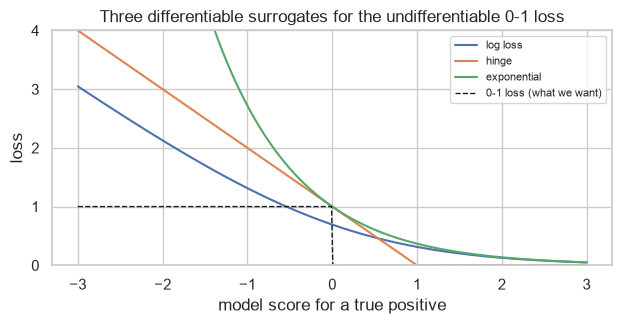

In [6]:
score = np.linspace(-3, 3, 400)        # raw model output for a case whose TRUE label is +1
prob = 1 / (1 + np.exp(-score))         # the sigmoid of 13.2

fig, ax = plt.subplots(figsize=(6.5, 3.4))
ax.plot(score, -np.log(prob), label="log loss")
ax.plot(score, np.maximum(0, 1 - score), label="hinge")
ax.plot(score, np.exp(-score), label="exponential")
ax.plot(score, (score < 0).astype(float), "k--", lw=1, label="0-1 loss (what we want)")
ax.set_ylim(0, 4)
ax.set_xlabel("model score for a true positive"); ax.set_ylabel("loss")
ax.set_title("Three differentiable surrogates for the undifferentiable 0-1 loss")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

All three upper-bound the 0-1 loss and are differentiable (hinge except at one point), which is what makes
gradient descent possible at all. Their differences matter:

* **Hinge** becomes exactly zero once the score passes 1 — correctly-classified points beyond the margin
  contribute nothing, which is why SVMs depend only on the support vectors (16.1).
* **Log loss** never reaches zero, so every point keeps nudging the fit; it also grows without bound for
  confident mistakes, which is 8.5.3's behaviour.
* **Exponential** grows fastest of all, making AdaBoost very sensitive to mislabelled points (19.2).

### 10.3 Convexity

A function is **convex** if the line segment between any two points on its graph lies above the graph.
Convexity is what makes optimization reliable:

| | Convex loss | Non-convex loss |
|---|---|---|
| Local minima | Exactly one, which is global | Possibly many |
| Result depends on initialization | **No** | **Yes** |
| Result depends on the random seed | No | Yes |
| Examples | Linear regression MSE, logistic log loss, SVM hinge | Neural networks, k-means (20.2), GMM (20.7) |

Every loss in Chapters 11–13 is convex, which is why those models return the same answer every time.

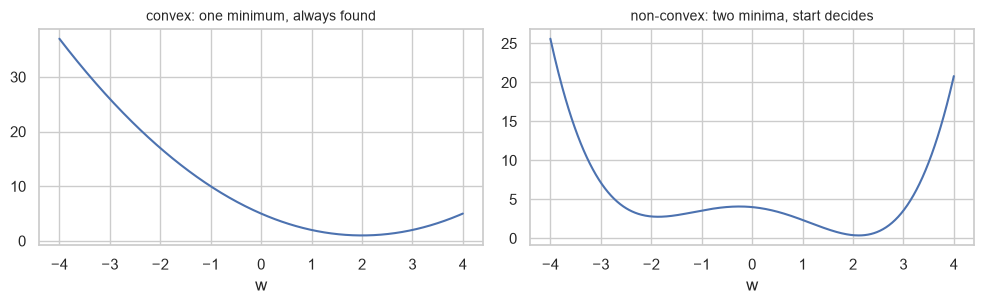

In [7]:
def convex(w):
    return (w - 2) ** 2 + 1

def non_convex(w):
    return 0.15 * w ** 4 - 1.2 * w ** 2 - 0.6 * w + 4


w = np.linspace(-4, 4, 400)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
for ax, (f, title) in zip(axes, [(convex, "convex: one minimum, always found"),
                                 (non_convex, "non-convex: two minima, start decides")]):
    ax.plot(w, f(w))
    ax.set_xlabel("w"); ax.set_title(title, fontsize=10)
fig.tight_layout()
plt.show()

In [8]:
def descend(f, grad, start, lr=0.02, steps=400):
    w = start
    for _ in range(steps):
        w -= lr * grad(w)
    return w


grad_convex = lambda w: 2 * (w - 2)
grad_non_convex = lambda w: 0.6 * w ** 3 - 2.4 * w - 0.6

print("convex loss, three starting points:")
for start in (-4.0, 0.0, 5.0):
    print(f"  start {start:>5.1f}  ->  {descend(convex, grad_convex, start):.4f}")

print("non-convex loss, three starting points:")
for start in (-4.0, 0.0, 5.0):
    print(f"  start {start:>5.1f}  ->  {descend(non_convex, grad_non_convex, start):.4f}")

convex loss, three starting points:
  start  -4.0  ->  2.0000
  start   0.0  ->  2.0000
  start   5.0  ->  2.0000
non-convex loss, three starting points:
  start  -4.0  ->  -1.8608
  start   0.0  ->  2.1149
  start   5.0  ->  2.1149


The convex loss returns the same answer from every start. The non-convex one does not — and that is the
practical reason k-means is run several times with different initializations and the best result kept
(`n_init`, 20.3), while `LinearRegression` needs no such parameter.

### 10.4 Gradient Descent from Scratch

The algorithm is one line, repeated:

$$\theta \leftarrow \theta - \alpha \nabla J(\theta)$$

Subtract the gradient (which points uphill, 2.6.1), scaled by a **learning rate** $\alpha$. For linear
regression with $J(\mathbf{w}) = \frac{1}{n}\lVert X\mathbf{w} - y \rVert^2$, 2.6.2 derived and verified

$$\nabla J = \frac{2}{n} X^\top (X\mathbf{w} - y)$$

In [9]:
def make_regression_data(n=200, seed=RANDOM_STATE):
    gen = np.random.default_rng(seed)
    X = gen.normal(size=(n, 3))
    X = np.column_stack([np.ones(n), X])          # column of ones = intercept
    w_true = np.array([5.0, 2.0, -1.0, 0.5])
    return X, X @ w_true + gen.normal(0, 0.3, n), w_true


X, y, W_TRUE = make_regression_data()
print("X:", X.shape, " true parameters:", W_TRUE)

X: (200, 4)  true parameters: [ 5.   2.  -1.   0.5]


In [10]:
def mse(X, y, w):
    return np.mean((X @ w - y) ** 2)


def mse_gradient(X, y, w):
    return 2 / len(y) * X.T @ (X @ w - y)


def gradient_descent(X, y, lr=0.1, n_iter=200, w0=None):
    """Batch gradient descent. Returns the final w and the loss at every step."""
    w = np.zeros(X.shape[1]) if w0 is None else w0.copy()
    history = np.empty(n_iter)
    for i in range(n_iter):
        history[i] = mse(X, y, w)
        w -= lr * mse_gradient(X, y, w)
    return w, history


w_gd, history = gradient_descent(X, y, lr=0.1, n_iter=200)

print("true       :", W_TRUE)
print("gradient descent:", w_gd.round(4))
print("final loss :", f"{history[-1]:.6f}")

true       : [ 5.   2.  -1.   0.5]
gradient descent: [ 4.9889  2.011  -1.0023  0.4845]
final loss : 0.092373


Against the closed-form solution of 11.3, and against scikit-learn:

In [11]:
w_closed = np.linalg.lstsq(X, y, rcond=None)[0]
sk = LinearRegression(fit_intercept=False).fit(X, y).coef_

print("gradient descent :", w_gd.round(5))
print("normal equation  :", w_closed.round(5))
print("scikit-learn     :", sk.round(5))
print("\nGD vs closed form agree to 3 decimals:", np.allclose(w_gd, w_closed, atol=1e-3))
print("closed form vs sklearn agree exactly  :", np.allclose(w_closed, sk))

gradient descent : [ 4.98888  2.01104 -1.00228  0.4845 ]
normal equation  : [ 4.98888  2.01104 -1.00228  0.4845 ]
scikit-learn     : [ 4.98888  2.01104 -1.00228  0.4845 ]

GD vs closed form agree to 3 decimals: True
closed form vs sklearn agree exactly  : True


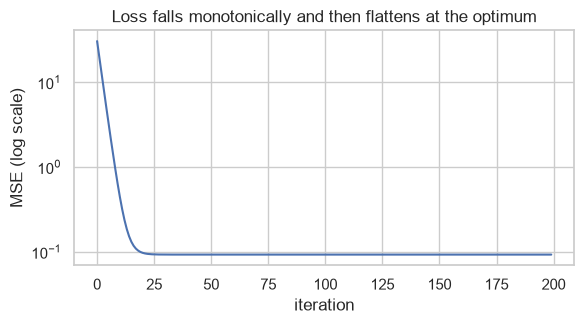

In [12]:
fig, ax = plt.subplots(figsize=(6, 3.4))
ax.plot(history)
ax.set_yscale("log")
ax.set_xlabel("iteration"); ax.set_ylabel("MSE (log scale)")
ax.set_title("Loss falls monotonically and then flattens at the optimum")
fig.tight_layout()
plt.show()

The flattening is the convergence signal (10.8.1). Once the curve is horizontal, further iterations cost
time and change nothing.

### 10.5 Batch, Stochastic and Mini-Batch

The gradient above is computed from **all** $n$ rows. That is exact and expensive. The alternatives trade
exactness for speed.

| Variant | Rows per update | Updates per epoch | Gradient is | Cost per update |
|---|---|---|---|---|
| **Batch** | All $n$ | 1 | Exact | $O(n)$ |
| **Stochastic (SGD)** | 1 | $n$ | Very noisy, correct on average | $O(1)$ |
| **Mini-batch** | $b$ (typically 32–256) | $n/b$ | Moderately noisy | $O(b)$ |

Mini-batch is the default everywhere in practice: it gets most of SGD's speed with much less noise, and it
maps well onto vectorized hardware.

In [13]:
def sgd(X, y, lr=0.01, n_epochs=30, batch_size=1, seed=RANDOM_STATE):
    gen = np.random.default_rng(seed)
    w = np.zeros(X.shape[1])
    n = len(y)
    history = []
    for _ in range(n_epochs):
        order = gen.permutation(n)                 # reshuffle every epoch
        for start in range(0, n, batch_size):
            idx = order[start:start + batch_size]
            w -= lr * mse_gradient(X[idx], y[idx], w)
            history.append(mse(X, y, w))            # full-data loss, for comparability
    return w, np.array(history)


w_batch, h_batch = gradient_descent(X, y, lr=0.1, n_iter=30)
w_sgd, h_sgd = sgd(X, y, lr=0.01, n_epochs=30, batch_size=1)
w_mini, h_mini = sgd(X, y, lr=0.05, n_epochs=30, batch_size=32)

for name, w_ in (("batch  ", w_batch), ("SGD    ", w_sgd), ("mini-32", w_mini)):
    print(f"{name}  w = {w_.round(3)}   final MSE {mse(X, y, w_):.5f}")
print(f"\ntrue      w = {W_TRUE}")

batch    w = [ 4.983  2.007 -1.002  0.48 ]   final MSE 0.09244
SGD      w = [ 4.956  2.021 -0.993  0.501]   final MSE 0.09395
mini-32  w = [ 4.978  2.011 -0.991  0.498]   final MSE 0.09280

true      w = [ 5.   2.  -1.   0.5]


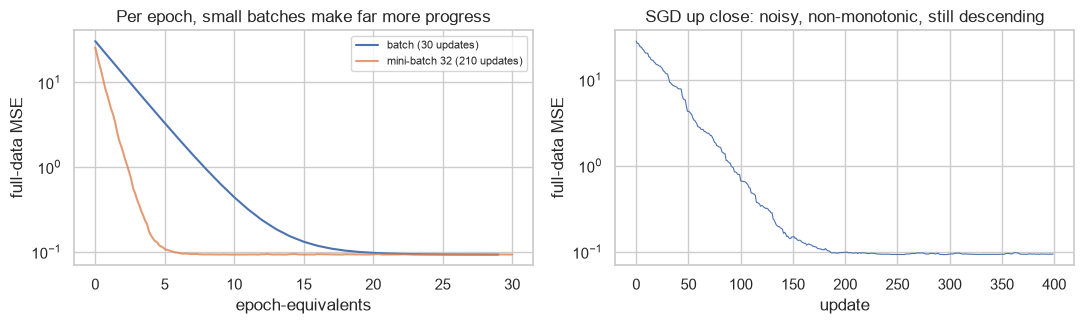

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))

axes[0].plot(h_batch, label=f"batch ({len(h_batch)} updates)")
axes[0].plot(np.linspace(0, len(h_batch), len(h_mini)), h_mini, alpha=0.8,
             label=f"mini-batch 32 ({len(h_mini)} updates)")
axes[0].set_xlabel("epoch-equivalents"); axes[0].set_ylabel("full-data MSE")
axes[0].set_yscale("log"); axes[0].set_title("Per epoch, small batches make far more progress")
axes[0].legend(fontsize=8)

axes[1].plot(h_sgd[:400], lw=0.8)
axes[1].set_xlabel("update"); axes[1].set_ylabel("full-data MSE")
axes[1].set_yscale("log")
axes[1].set_title("SGD up close: noisy, non-monotonic, still descending")

fig.tight_layout()
plt.show()

The right panel is the defining property of SGD: **the loss does not fall monotonically.** Each update uses
one row, so it improves that row and may worsen others. Only the average direction is correct.

That noise is not purely a cost. On a non-convex surface (10.3) it can knock the iterate out of a shallow
local minimum, which is one reason stochastic methods are standard for hard problems.

### 10.6 The Learning Rate

The learning rate is the single most consequential hyperparameter in gradient descent, and its failure
modes are distinctive.

| Too small | Just right | Too large |
|---|---|---|
| Converges, very slowly | Converges quickly | **Diverges** — loss grows without bound |
| Loss curve nearly flat | Loss curve drops then flattens | Loss curve rises, or oscillates |
| Fix: increase it | — | Fix: decrease it |

In [15]:
print(f"{'learning rate':>15}{'final MSE':>16}{'behaviour':>14}")
for lr in (0.0005, 0.01, 0.1, 0.6, 1.05):
    _, h = gradient_descent(X, y, lr=lr, n_iter=200)
    final = h[-1]
    if not np.isfinite(final) or final > h[0]:
        behaviour = "DIVERGED"
    elif final > 0.5:
        behaviour = "too slow"
    else:
        behaviour = "converged"
    print(f"{lr:>15}{final:>16.4g}{behaviour:>14}")

  learning rate       final MSE     behaviour
         0.0005           20.42      too slow
           0.01          0.1026     converged
            0.1         0.09237     converged
            0.6         0.09237     converged
           1.05       3.118e+40      DIVERGED


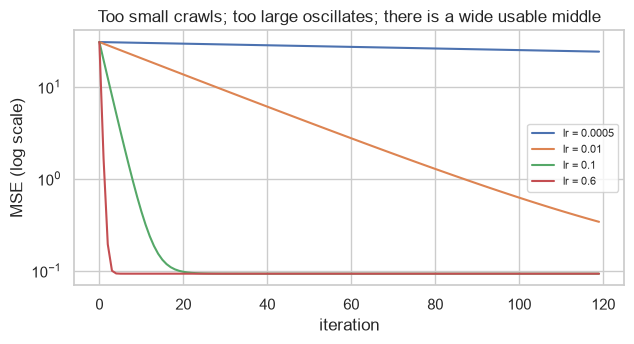

In [16]:
fig, ax = plt.subplots(figsize=(6.5, 3.6))
for lr in (0.0005, 0.01, 0.1, 0.6):
    _, h = gradient_descent(X, y, lr=lr, n_iter=120)
    ax.plot(h, label=f"lr = {lr}")
ax.set_yscale("log")
ax.set_xlabel("iteration"); ax.set_ylabel("MSE (log scale)")
ax.set_title("Too small crawls; too large oscillates; there is a wide usable middle")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

**Common mistake — diagnosing divergence as a modelling problem.** A loss that grows, or becomes `nan`, is
almost always a learning rate that is too large, not a bug in the gradient. The check is one line: halve
the learning rate and see whether the symptom disappears.

In [17]:
_, diverged = gradient_descent(X, y, lr=1.05, n_iter=40)
print("lr = 1.05, first 8 losses:", np.array2string(diverged[:8], precision=1))
print("... final:", diverged[-1])

_, halved = gradient_descent(X, y, lr=0.5, n_iter=40)
print("\nlr = 0.5,  first 8 losses:", np.array2string(halved[:8], precision=4))
print("... final:", f"{halved[-1]:.6f}")

lr = 1.05, first 8 losses: [ 30.5  39.   52.1  71.9 101.6 146.1 212.8 313. ]
... final: 379655753.15838164

lr = 0.5,  first 8 losses: [30.4913  0.2077  0.0935  0.0924  0.0924  0.0924  0.0924  0.0924]
... final: 0.092373


#### 10.6.1 Feature scaling changes the geometry

5.5 asserted that unscaled features slow gradient descent. Here is why: unequal feature scales stretch the
loss surface into a long narrow valley, and the gradient points across the valley rather than along it, so
descent zig-zags.

In [18]:
gen = np.random.default_rng(0)
n = 300
raw = np.column_stack([
    np.ones(n),
    gen.normal(0, 1, n),           # scale 1
    gen.normal(0, 1000, n),        # scale 1000
])
y_raw = raw @ np.array([1.0, 2.0, 0.01]) + gen.normal(0, 0.5, n)

scaled = raw.copy()
scaled[:, 1:] = (raw[:, 1:] - raw[:, 1:].mean(axis=0)) / raw[:, 1:].std(axis=0)
y_scaled = y_raw

for label, Xv, yv, lr in (("unscaled", raw, y_raw, 1e-7), ("scaled", scaled, y_scaled, 0.1)):
    _, h = gradient_descent(Xv, yv, lr=lr, n_iter=300)
    print(f"{label:<9} usable lr {lr:<8}  loss after 300 iters {h[-1]:>12.4f}")

unscaled  usable lr 1e-07     loss after 300 iters       5.2749
scaled    usable lr 0.1       loss after 300 iters       0.2134


The unscaled problem needs a learning rate a million times smaller merely to avoid diverging — because the
step must be small enough for the largest-scale feature, which makes it far too small for the others. After
the same 300 iterations it has barely moved.

The **condition number** of $X^\top X$ (2.4.1) quantifies this exactly: it is the ratio of the valley's
length to its width, and it bounds how fast gradient descent can converge.

In [19]:
print(f"cond(X^T X), unscaled : {np.linalg.cond(raw.T @ raw):.3e}")
print(f"cond(X^T X), scaled   : {np.linalg.cond(scaled.T @ scaled):.3e}")

cond(X^T X), unscaled : 9.724e+05
cond(X^T X), scaled   : 1.088e+00


### 10.7 Momentum and Adaptive Steps

Plain gradient descent takes the same-sized step in whatever direction the gradient currently points, which
is what causes the zig-zagging of 10.6.1. **Momentum** accumulates a running average of past gradients, so
consistent directions build up speed and oscillating ones cancel:

$$v \leftarrow \beta v + \nabla J(\theta), \qquad \theta \leftarrow \theta - \alpha v$$

In [20]:
def gd_momentum(X, y, lr=0.1, beta=0.9, n_iter=200):
    w = np.zeros(X.shape[1])
    v = np.zeros_like(w)
    history = np.empty(n_iter)
    for i in range(n_iter):
        history[i] = mse(X, y, w)
        v = beta * v + mse_gradient(X, y, w)
        w -= lr * v
    return w, history


# A deliberately ill-conditioned problem, where plain GD struggles.
gen = np.random.default_rng(1)
Xi = np.column_stack([np.ones(200), gen.normal(0, 1, 200), gen.normal(0, 0.05, 200)])
yi = Xi @ np.array([1.0, 2.0, 3.0]) + gen.normal(0, 0.1, 200)

_, h_plain = gradient_descent(Xi, yi, lr=0.3, n_iter=300)
_, h_mom = gd_momentum(Xi, yi, lr=0.3, beta=0.9, n_iter=300)

print(f"cond(X^T X): {np.linalg.cond(Xi.T @ Xi):.1f}")
print(f"plain GD,   loss after 300 iters: {h_plain[-1]:.6f}")
print(f"momentum,   loss after 300 iters: {h_mom[-1]:.6f}")
print(f"iterations for plain GD to reach momentum's final loss: "
      f"{'never' if h_plain.min() > h_mom[-1] else int(np.argmax(h_plain <= h_mom[-1]))}")

cond(X^T X): 515.6
plain GD,   loss after 300 iters: 0.016167
momentum,   loss after 300 iters: 0.009848
iterations for plain GD to reach momentum's final loss: never


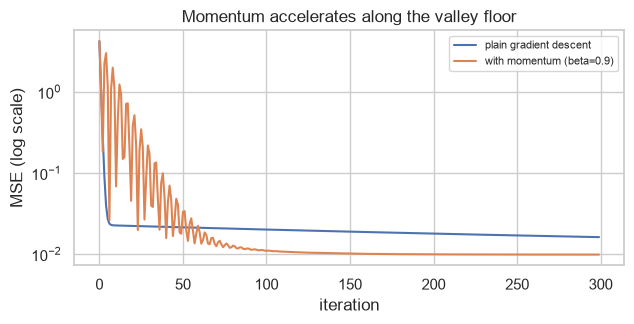

In [21]:
fig, ax = plt.subplots(figsize=(6.5, 3.4))
ax.plot(h_plain, label="plain gradient descent")
ax.plot(h_mom, label="with momentum (beta=0.9)")
ax.set_yscale("log")
ax.set_xlabel("iteration"); ax.set_ylabel("MSE (log scale)")
ax.set_title("Momentum accelerates along the valley floor")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

| Method | Idea | Where it appears in this material |
|---|---|---|
| **Momentum** | Average past gradients | `SGDRegressor`, boosting solvers |
| **Nesterov momentum** | Look ahead before stepping | `SGDClassifier(nesterov=...)` in some libraries |
| **AdaGrad** | Per-parameter step, shrinking with accumulated gradient | Sparse text features |
| **RMSProp** | AdaGrad with a decaying average, so steps stop shrinking | — |
| **Adam** | Momentum + RMSProp | The default in deep learning; out of scope here (1.7) |
| **L-BFGS** | Uses curvature, not just slope | `LogisticRegression(solver="lbfgs")` — the default |

The last row matters most for this material: scikit-learn's default logistic-regression solver is not
gradient descent at all. **L-BFGS** approximates the second derivative and typically converges in tens of
iterations rather than thousands — which is affordable because classical models have few parameters.

In [22]:
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
import time

Xc, yc = make_classification(n_samples=4000, n_features=20, n_informative=10,
                             random_state=RANDOM_STATE)
Xc = StandardScaler().fit_transform(Xc)

for name, model in (("lbfgs (default)", LogisticRegression(max_iter=1000)),
                    ("liblinear", LogisticRegression(solver="liblinear")),
                    ("SGD, 50 epochs", SGDClassifier(loss="log_loss", max_iter=50, tol=None,
                                                     random_state=RANDOM_STATE))):
    t0 = time.perf_counter()
    model.fit(Xc, yc)
    elapsed = (time.perf_counter() - t0) * 1000
    print(f"{name:<18} accuracy {model.score(Xc, yc):.4f}   {elapsed:>6.1f} ms")

lbfgs (default)    accuracy 0.8053      4.0 ms
liblinear          accuracy 0.8050      4.7 ms
SGD, 50 epochs     accuracy 0.7758     17.6 ms


### 10.8 Closed Form versus Iterative

Some losses can be minimized by solving an equation instead of iterating. Linear regression is the standard
example: setting $\nabla J = 0$ gives the **normal equation** $\mathbf{w} = (X^\top X)^{-1}X^\top y$
(11.3), which is exact and needs no learning rate.

| | Closed form | Iterative |
|---|---|---|
| Exists for | Linear regression, ridge | Almost everything else |
| Hyperparameters | **None** | Learning rate, iterations, batch size |
| Cost | $O(np^2 + p^3)$ — cubic in features | $O(np)$ per iteration |
| Scales with $n$ | Poorly (must form $X^\top X$) | **Well** — mini-batches never load all of it |
| Scales with $p$ | **Poorly** | Well |
| Numerical risk | Ill-conditioning (2.9) | Divergence, slow convergence |
| Exactness | Exact | Approximate, to a tolerance |

In [23]:
def normal_equation(X, y):
    return np.linalg.solve(X.T @ X, X.T @ y)     # solve, never inv (2.4)


print(f"{'p (features)':>13}{'closed form (ms)':>19}{'gradient descent (ms)':>23}")
for p in (10, 100, 400):
    gen = np.random.default_rng(p)
    Xp = gen.normal(size=(3000, p))
    yp = Xp @ gen.normal(size=p) + gen.normal(0, 0.5, 3000)

    t0 = time.perf_counter(); normal_equation(Xp, yp); t_closed = (time.perf_counter() - t0) * 1000
    t0 = time.perf_counter(); gradient_descent(Xp, yp, lr=0.05, n_iter=200)
    t_gd = (time.perf_counter() - t0) * 1000

    print(f"{p:>13}{t_closed:>19.2f}{t_gd:>23.2f}")

 p (features)   closed form (ms)  gradient descent (ms)
           10               0.14                   6.95


          100              32.93                 168.68

          400             689.19                 783.63


At these sizes the closed form wins outright, and its cost grows roughly with $p^3$ as predicted. The
crossover depends on both $n$ and $p$, and on this scale it has not been reached.

That is worth stating plainly, because the usual claim — "gradient descent is faster" — is false for
problems of this size. **The real argument for iterative methods is memory, not speed**: the normal
equation must form $X^\top X$ and factorize it, while mini-batch SGD never holds more than $b$ rows at
once. When $n$ is 100 million or $X$ does not fit in RAM, the closed form is not slow — it is impossible.

#### 10.8.1 Convergence diagnostics

An iterative solver needs a stopping rule. The three standard ones, and what each misses:

| Rule | Stops when | Misses |
|---|---|---|
| Max iterations | A fixed budget is spent | Whether it actually converged |
| Loss change | $\lvert J_t - J_{t-1}\rvert < \text{tol}$ | A flat region that is not the optimum |
| Gradient norm | $\lVert \nabla J \rVert < \text{tol}$ | Nothing much — the most principled |

In [24]:
def gradient_descent_with_stop(X, y, lr=0.1, max_iter=5000, tol=1e-8):
    w = np.zeros(X.shape[1])
    for i in range(max_iter):
        g = mse_gradient(X, y, w)
        if np.linalg.norm(g) < tol:
            return w, i, "gradient norm below tol"
        w -= lr * g
    return w, max_iter, "hit max_iter (may not have converged)"


for lr in (0.3, 0.05, 0.005):
    w_, iters, why = gradient_descent_with_stop(X, y, lr=lr, tol=1e-6)
    print(f"lr {lr:<7} stopped after {iters:>5} iterations: {why}")

lr 0.3     stopped after    22 iterations: gradient norm below tol
lr 0.05    stopped after   170 iterations: gradient norm below tol
lr 0.005   stopped after  1758 iterations: gradient norm below tol


**Common mistake — ignoring a convergence warning.** `ConvergenceWarning` means the solver hit its
iteration limit with the gradient still large, so the returned parameters are wherever it happened to stop.
The score is then not the model's score; it is the score of an unfinished fit.

In [25]:
import warnings
from sklearn.metrics import roc_auc_score

# 25 features whose scales span four orders of magnitude - a genuinely hard surface (10.6.1).
Xw, yw = make_classification(n_samples=800, n_features=25, n_informative=12,
                             random_state=RANDOM_STATE)
Xw = Xw * np.logspace(0, 4, 25)

print(f"{'max_iter':>10}{'n_iter used':>13}{'accuracy':>11}{'ROC AUC':>10}{'warned':>9}")
for max_iter in (3, 10, 50, 5000):
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        m = LogisticRegression(max_iter=max_iter).fit(Xw, yw)
        warned = len(caught) > 0
    p = m.predict_proba(Xw)[:, 1]
    print(f"{max_iter:>10}{m.n_iter_[0]:>13}{m.score(Xw, yw):>11.4f}"
          f"{roc_auc_score(yw, p):>10.4f}{str(warned):>9}")

  max_iter  n_iter used   accuracy   ROC AUC   warned
         3            3     0.6637    0.7088     True
        10           10     0.7588    0.8294     True
        50           50     0.7662    0.8394     True


      5000         5000     0.8137    0.9046     True


Every row warns, including the last: even **5000 iterations is not enough** on this surface. And the AUC
of the truncated fits is not a rounding difference — 0.709 at three iterations against 0.905 at five
thousand. Anyone who silenced the warning and reported the first number would be reporting the score of an
optimizer that had barely started.

In [26]:
Xw_scaled = StandardScaler().fit_transform(Xw)

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    m_scaled = LogisticRegression(max_iter=5000).fit(Xw_scaled, yw)
    warned = len(caught) > 0

p_scaled = m_scaled.predict_proba(Xw_scaled)[:, 1]
print(f"scaled first: n_iter {m_scaled.n_iter_[0]}   accuracy {m_scaled.score(Xw_scaled, yw):.4f}"
      f"   ROC AUC {roc_auc_score(yw, p_scaled):.4f}   warned {warned}")
print("\n5000 unscaled iterations reach AUC 0.905; 12 scaled iterations reach 0.906.")

scaled first: n_iter 12   accuracy 0.8237   ROC AUC 0.9064   warned False

5000 unscaled iterations reach AUC 0.905; 12 scaled iterations reach 0.906.


**Scaling is the fix, not a larger `max_iter`.** Twelve iterations on scaled features beat five thousand on
unscaled ones — a factor of 400 in work, for a better answer. Raising `max_iter` treats the symptom and
makes every subsequent retrain slower.

### 10.9 In Practice

#### 10.9.1 Where this shows up: a model that will not train

Optimization rarely appears as a topic in real work. It appears as a **symptom** — a fit that is slow, a
score that is worse than it should be, a warning nobody reads — and the diagnostic path is short if you
know it.

The scenario: a colleague reports that logistic regression on the churn data "doesn't work — it takes
forever and the accuracy is bad." The data is the same data that reached 0.815 AUC in 9.9.1.

In [27]:
DOMAIN_RULES = {"age": (16, 100), "satisfaction_score": (1, 10), "monthly_charges": (0, 500)}

data = pd.read_csv("data/customers.csv").drop_duplicates()
data["total_charges"] = pd.to_numeric(data["total_charges"], errors="coerce")
data.loc[data["total_charges"].isna() & (data["tenure_months"] <= 1), "total_charges"] = 0.0
for col, (lo, hi) in DOMAIN_RULES.items():
    data[col] = data[col].where(data[col].between(lo, hi))

NUMERIC = ["age", "tenure_months", "monthly_charges", "total_charges",
           "support_tickets", "last_login_days", "satisfaction_score"]
X_ch = data[NUMERIC].fillna(data[NUMERIC].median())
y_ch = data["churned"]

print(X_ch.describe().loc[["mean", "std", "max"]].round(1).to_string())

       age  tenure_months  monthly_charges  total_charges  support_tickets  last_login_days  satisfaction_score
mean  37.9           36.5             40.3         1486.2              1.3             12.4                 7.3
std   10.9           20.8             16.8         1128.8              1.1              8.5                 1.6
max   76.0           72.0             89.7         6247.5              6.0             51.0                10.0


**Step 1 — look at the feature scales.** `total_charges` ranges into the thousands while
`satisfaction_score` is 1–10. That is a condition-number problem waiting to happen (10.6.1).

In [28]:
Xn = np.column_stack([np.ones(len(X_ch)), X_ch.to_numpy()])
print(f"condition number of X^T X, raw    : {np.linalg.cond(Xn.T @ Xn):.3e}")

X_std = X_ch.to_numpy()
X_std = (X_std - X_std.mean(axis=0)) / X_std.std(axis=0)
Xs = np.column_stack([np.ones(len(X_std)), X_std])
print(f"condition number of X^T X, scaled : {np.linalg.cond(Xs.T @ Xs):.3e}")

condition number of X^T X, raw    : 3.362e+08
condition number of X^T X, scaled : 3.677e+01


**Step 2 — reproduce the complaint, and measure it.**

In [29]:
# scikit-learn's default is max_iter=100 - which is exactly what the colleague ran.
for label, Xv, max_iter in (("unscaled, default max_iter=100", X_ch, 100),
                            ("unscaled, max_iter=1000", X_ch, 1000),
                            ("SCALED, default max_iter=100", X_std, 100)):
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        t0 = time.perf_counter()
        fit = LogisticRegression(max_iter=max_iter).fit(Xv, y_ch)
        elapsed = (time.perf_counter() - t0) * 1000
        warned = len(caught) > 0
    auc = roc_auc_score(y_ch, fit.predict_proba(Xv)[:, 1])
    print(f"{label:<32} n_iter {fit.n_iter_[0]:>4}   {elapsed:>6.1f} ms"
          f"   AUC {auc:.4f}   warned {warned}")

unscaled, default max_iter=100   n_iter  100     32.1 ms   AUC 0.8201   warned True
unscaled, max_iter=1000          n_iter  228     45.4 ms   AUC 0.8246   warned False
SCALED, default max_iter=100     n_iter   13      3.1 ms   AUC 0.8248   warned False


Both complaints reproduce, and both are optimization artefacts:

* At the **default** `max_iter=100`, the unscaled fit hits the iteration cap, raises `ConvergenceWarning`,
  and scores 0.820 — that is the "bad accuracy".
* Allowing 1000 iterations lets it converge properly at 228 iterations and 0.825 — that is the "takes
  forever".
* **Scaled, it converges in 13 iterations** and reaches the same 0.825, comfortably inside the default cap.

Seventeen times fewer iterations, no warning, and the better score — from one preprocessing step that
changes nothing about the model.

In [30]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
auc_default = cross_val_score(LogisticRegression(), X_ch, y_ch, cv=cv, scoring="roc_auc").mean()
auc_scaled = cross_val_score(LogisticRegression(), X_std, y_ch, cv=cv, scoring="roc_auc").mean()

print(f"CV ROC AUC, unscaled at the default max_iter : {auc_default:.4f}")
print(f"CV ROC AUC, scaled   at the default max_iter : {auc_scaled:.4f}")

CV ROC AUC, unscaled at the default max_iter : 0.8175
CV ROC AUC, scaled   at the default max_iter : 0.8178


D:\Study Materials\ML\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
D:\Study Materials\ML\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please a

**Step 3 — the diagnosis.** The colleague's two complaints have one cause and one fix. Scaling drops the
condition number from $3.4 \times 10^{8}$ to about 37, the solver converges in 13 iterations instead of
hitting a cap at 100, and the score recovers — not because the model changed, but because the optimizer
now actually reaches the minimum it was always aiming at.

Note what the honest version of this report does **not** claim. The converged unscaled model and the scaled
model score within 0.001 of each other, so scaling did not make the model better; it made the *optimizer*
finish. The accuracy complaint was real only because the default iteration cap silently truncated the fit.

The general form of this diagnostic path:

```text
  slow fit / bad score / ConvergenceWarning
              |
              v
  [1] are the features on comparable scales?  -----> no  -> scale them (5.5, 10.6.1)
              | yes
              v
  [2] is the condition number large?  --------------> yes -> scale, or regularize (2.4.2)
              | no
              v
  [3] does raising max_iter change the answer? -----> yes -> it had not converged (10.8.1)
              | no
              v
  [4] does a different solver help? ----------------> lbfgs / liblinear / saga (10.7)
              | no
              v
  [5] the optimizer is fine. The problem is the model or the features (9.9.1)
```

Steps 1 and 2 resolve the large majority of real cases, which is why "scale your features" is such
common advice — and why it is worth knowing *why* rather than following it by reflex.

#### 10.9.2 When to reach for what

| Situation | Use | Not |
|---|---|---|
| Linear regression, $p$ in the hundreds, $n$ moderate | Closed form (`LinearRegression`) | Gradient descent |
| Linear regression, $p$ very large or $n$ enormous | `SGDRegressor` | The normal equation (10.8) |
| Logistic regression, ordinary size | `lbfgs` (the default) | Hand-rolled gradient descent |
| L1 penalty (12.3) | `liblinear` or `saga` | `lbfgs` — it cannot handle the kink |
| Data does not fit in memory | Mini-batch SGD with `partial_fit` | Anything batch |
| Outliers are genuine and frequent | Huber loss (10.2.1) | Squared loss |
| The score must be reproducible exactly | A convex loss (10.3) | Non-convex, unless the seed is fixed |
| `ConvergenceWarning` appears | Scale first, then raise `max_iter` | Silencing the warning |
| Loss becomes `nan` | Halve the learning rate (10.6) | Debugging the gradient first |

#### 10.9.3 What goes wrong in production

| Failure | What it looks like | Where |
|---|---|---|
| **`ConvergenceWarning` suppressed** | The model ships half-fitted; the score is of an unfinished optimization | 10.8.1 |
| **Scaler fitted on the wrong data** | Feature scales shift, the solver's iteration count changes, results move | 5.1 |
| **Learning rate tuned for the old data volume** | Retraining on 10× the data diverges or crawls | 10.6 |
| **Non-convex model re-fitted without a seed** | Retraining produces a materially different model with the same code | 10.3 |
| **`max_iter` raised instead of scaling** | The fit gets slower every retrain and never converges properly | 10.9.1 |
| **float32 in serving, float64 in training** | Small numerical drift, amplified by ill-conditioning | 2.9.3 |

The first row is the one that actually reaches production, because the failure is a *warning* rather than
an error, and warnings are routinely silenced in pipeline code. A half-converged logistic regression
returns coefficients, makes predictions, and scores plausibly — it simply is not the model anyone intended
to fit. Treat `ConvergenceWarning` as a build failure, not as noise.

In [31]:
# --- 10. Optimization and Gradient Descent — scratch cell ---# Experiments for this chapter. Promote anything worth keeping into the# relevant section as a proper example cell.